# Perceptron Learning API

In [59]:
import numpy as np

In [60]:
class Perceptron:

    def __init__(self,eta=0.01,n_iter=50,random_state=1):
        self.eta = eta  #Learning rate
        self.n_iter=n_iter  #Iterations on Dataset(Epoch)
        self.random_state=random_state  #Random number generator seed for random Weight

    def fit(self,x,y): #Fit Training Data
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0,scale=0.01,size=x.shape[1]) #Gausian Dist of mean 0 and sd 0.01 of size (size)
        self.b_ = np.float64(0.)
        self.errors_ = []

        for _ in range(self.n_iter):
            errors = 0
            for xi,yi in zip(x,y):
                update = self.eta*(yi-self.predict(xi))
                self.w_ += update*xi
                self.b_ += update
                errors += int(update!=0.0)
            self.errors_.append(errors)
        return self

    def net_input(self,x):
        return np.dot(x,self.w_)+self.b_

    def predict(self,x):
        return np.where(self.net_input(x)>=0,1,0) #if condn is True then 1 else 0

# Using Iris dataset and predicting the class by Perceptron API

In [61]:
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt

#loading Iris
iris = load_iris(as_frame=True)
df = iris.frame

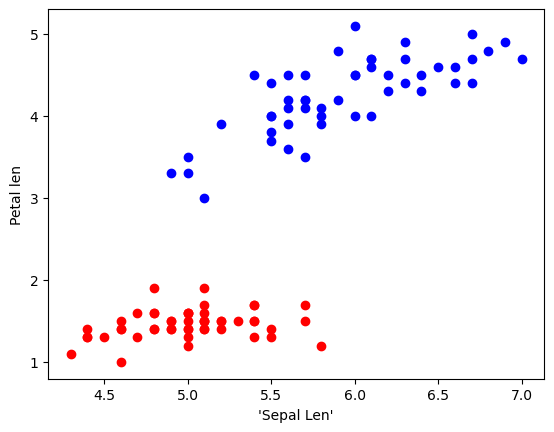

In [62]:
df.head()
y = df.iloc[0:100,4] #getting only 2 classes data target values
X = df.iloc[0:100,[0,2]] #getting 2 classes input values

#plotting the both features on scatter plot
plt.scatter(X.iloc[:50,0],X.iloc[:50,1],color='red') 
plt.scatter(X.iloc[50:100,0],X.iloc[50:100,1],color='blue')
plt.xlabel("'Sepal Len'")
plt.ylabel("Petal len")
plt.show()

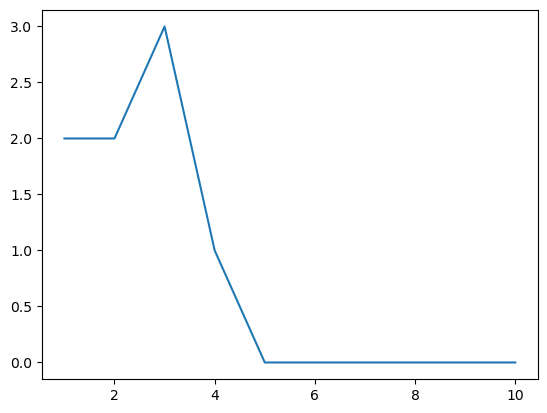

In [63]:
#Applying Perceptron
per = Perceptron(n_iter=10)
per.fit(X.values,y)
plt.plot(range(1,len(per.errors_)+1),per.errors_)

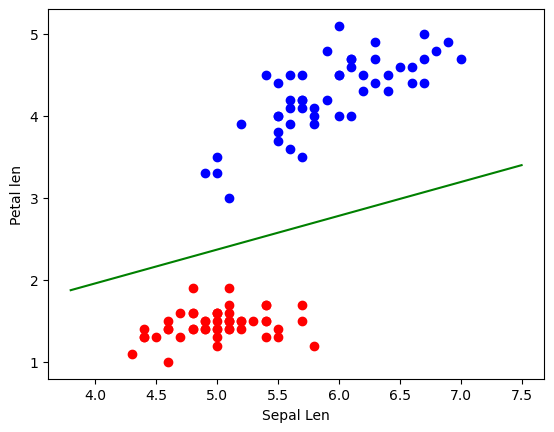

In [64]:
#plotting the linear decision boundary
x1_min = X.iloc[:, 0].min() - 0.5
x1_max = X.iloc[:, 0].max() + 0.5
x1_values = np.linspace(x1_min, x1_max, 100)

x2_values = -(per.w_[0] * x1_values + per.b_) / per.w_[1]

plt.scatter(X.iloc[:50,0],X.iloc[:50,1],color='red')
plt.scatter(X.iloc[50:100,0],X.iloc[50:100,1],color='blue')
plt.plot(x1_values,x2_values,color='green')
plt.xlabel("Sepal Len")
plt.ylabel("Petal len")
plt.show()